# Cohort quality control - triage a folder of slides

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/06_cohort_quality_control.ipynb)

[Notebook 05](05_quality_control.ipynb) inspected one slide. Here we **triage a whole
folder**: run GrandQC's artifact stage over every slide, score how much of each is
out-of-focus / folded / pen-marked / bubbled, and **rank the cohort** so the dirtiest
slides come first. This is the QC pass you run before committing a cohort to
training - it's fast (one forward per slide) and parallel across slides.

> GrandQC weights are **CC-BY-NC-SA-4.0 (non-commercial)**, fetched on first use.

In [1]:
# Bootstrap: works on Colab and a local install.
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None
EXTRAS = "zarr,image,torch,models,grandqc"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.1.0) for reproducibility
if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

import glob, os, tempfile
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch

import raw2features
from raw2features.readers.omezarr import OmeZarrReader
from raw2features.viz import render_thumbnail
from raw2features.qc.grandqc import GrandQC

mpl.rcParams["figure.dpi"] = 88
DEV = "cuda" if torch.cuda.is_available() else "cpu"
ARTS = ["tissue_fold", "darkspot_foreign", "pen_marking", "airbubble_edge", "out_of_focus"]
print("raw2features", raw2features.__version__, "| device", DEV)

raw2features 0.1.0 | device cuda


## 1. A folder of slides

Point `SLIDES` at a directory of OME-Zarr (`R2F_SLIDES`). With nothing local we triage a few
real public H&E slides from the
[BioImage Archive](https://www.ebi.ac.uk/biostudies/studies/S-BIAD1285) (the SurGen study),
so the ranking reflects genuine tissue.

> The BIA OME-Zarr URLs may change over time; only the accession is permanent (see
> [`02_visual_walkthrough.ipynb`](02_visual_walkthrough.ipynb)).

In [2]:
import urllib.request, xml.etree.ElementTree as ET

_BIA_S3 = "https://uk1s3.embassy.ebi.ac.uk/bia-integrator-data"
_NS = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}

def _bia_prefixes(prefix):
    url = f"{_BIA_S3}?list-type=2&prefix={prefix}&delimiter=/"
    root = ET.fromstring(urllib.request.urlopen(url, timeout=60).read())
    return [p.text for p in root.findall(".//s3:CommonPrefixes/s3:Prefix", _NS)]

def surgen_slides(n, accession="S-BIAD1285"):
    """Resolve up to n *readable* public OME-Zarr H&E URIs from a BioImage Archive study.

    Some depositions include reps we can't open as a pyramid; we skip those so the demo
    always lands on usable slides.
    """
    out = []
    for img in _bia_prefixes(f"{accession}/"):
        for rep in _bia_prefixes(img):
            if not rep.rstrip("/").endswith(".ome.zarr"):
                continue
            url = f"{_BIA_S3}/{rep.rstrip('/')}"
            try:
                with OmeZarrReader(url) as r:
                    r.level_downsamples()
                out.append(url)
            except Exception:
                pass
            break
        if len(out) >= n:
            break
    return out

slide_dir = os.environ.get("R2F_SLIDES", "../dev-data")
SLIDES = [s for s in sorted(glob.glob(os.path.join(slide_dir, "*.zarr")))
          if "multiplex" not in s]
if not SLIDES:
    SLIDES = surgen_slides(3)  # triage a few real public SurGen slides
    print("no local slides - streaming public SurGen slides from the BioImage Archive")
print(f"{len(SLIDES)} slide(s) to triage")

no local slides - streaming public SurGen slides from the BioImage Archive
3 slide(s) to triage


## 2. Scan each slide

GrandQC's artifact stage labels every pixel; we tally, over detected tissue, the fraction
that is each artifact class. We run it tuned for this cohort: **Macenko** normalization
(`stain_norm="macenko"`) for the stain, and a coarser **artifact scale**
(`artifact_mpp="2.0"`, less focus-sensitive) for the softer scans - out-of-the-box GrandQC
badly over-flags a differently-stained, softer-scanned cohort (see the before/after in
[`05_quality_control.ipynb`](05_quality_control.ipynb)). It also expects a **white**
background, but many WSIs pad with **black** (read as dark pen), so we mask near-black
pixels using the raw image (`artifact_image`) first.

In [3]:
def scan_slide(path):
    gq = GrandQC(device=DEV, artifact_mpp="2.0", stain_norm="macenko")
    with OmeZarrReader(path) as r:
        raster, _ = gq.artifact_raster(r)
        img, _ = gq.artifact_image(r)   # same image, for the canvas mask below
    hh, ww = min(raster.shape[0], img.shape[0]), min(raster.shape[1], img.shape[1])
    raster = raster[:hh, :ww].copy()
    raster[img[:hh, :ww].max(2) < 10] = 0          # mask black canvas padding
    c = np.bincount(raster.ravel(), minlength=8).astype(float)
    t = c[1:7].sum() or 1.0                          # detected tissue (classes 1-6)
    row = {a: c[i] / t for a, i in zip(ARTS, range(2, 7))}
    row["artifact_frac"] = c[2:7].sum() / t
    row["tissue_px"] = int(c[1:7].sum())   # detected tissue area (for the low-tissue filter)
    return row

rows = []
for s in SLIDES:
    name = os.path.basename(s.rstrip("/")).replace(".ome.zarr", "").replace(".zarr", "")
    try:
        r = scan_slide(s)
    except Exception as e:                       # cohorts contain unreadable/failed slides
        print(f"  skipped {name[:18]}: {type(e).__name__}")
        continue
    r["slide"] = name
    rows.append(r)
    print(f"  {r['slide']:20s} artifact_frac={r['artifact_frac']:.3f}")
scan = pd.DataFrame(rows).set_index("slide")

  b2f711e1-8088-4d67-937e-2ff20e2f89d2 artifact_frac=0.014


  0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd artifact_frac=0.056


  7a6e95ef-b6ec-4137-8ccf-b32f78d2271e artifact_frac=0.063


## 3. Rank the cohort

Sorted by total artifact fraction. On a real cohort the dirtiest slides - heavy
out-of-focus, big folds, pen - appear at the top; this is your worklist.

,tissue_fold,darkspot_foreign,pen_marking,airbubble_edge,out_of_focus,artifact_frac,tissue_px
slide,,,,,,,
7a6e95ef-b6ec-4137-8ccf-b32f78d2271e,0.027,0.000,0.002,0.003,0.031,0.063,58235497.000
0307ffb9-8dd6-4314-a4c0-2949b1e0b2bd,0.012,0.002,0.041,0.000,0.001,0.056,2572447.000
b2f711e1-8088-4d67-937e-2ff20e2f89d2,0.007,0.001,0.004,0.001,0.002,0.014,24585120.000


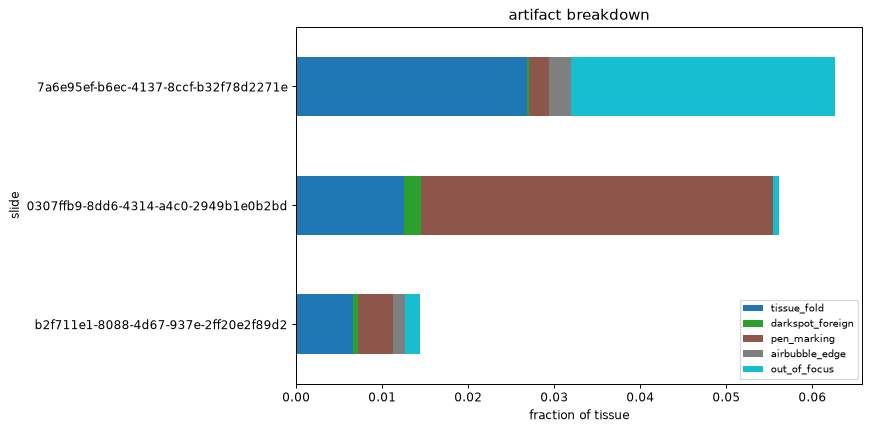

In [4]:
ranked = scan.sort_values("artifact_frac", ascending=False)
display(ranked.style.format("{:.3f}").background_gradient(
    subset=["artifact_frac", "out_of_focus"], cmap="Reds"))

ax = ranked[ARTS].head(12).plot.barh(stacked=True, figsize=(10, 5),
                                     colormap="tab10")
ax.invert_yaxis(); ax.set_xlabel("fraction of tissue"); ax.set_title("artifact breakdown")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout()

## 4. Look at the worst - the class raster

Thumbnail vs GrandQC's per-pixel classes for the dirtiest slide. Bright artifact regions
should line up with something visibly wrong in the tissue.

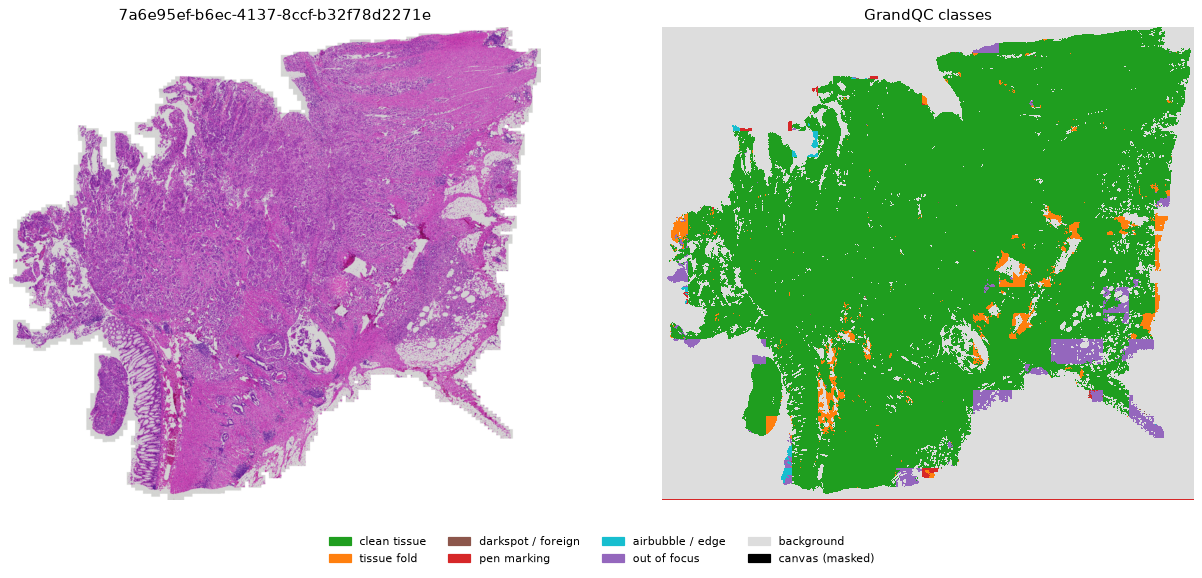

In [5]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
# GrandQC class index -> display colour + label (0 = masked canvas / unscored).
COL = ["#000000", "#1f9e1f", "#ff7f0e", "#8c564b", "#d62728", "#17becf", "#9467bd", "#dddddd"]
KEY = {1: "clean tissue", 2: "tissue fold", 3: "darkspot / foreign", 4: "pen marking",
       5: "airbubble / edge", 6: "out of focus", 7: "background", 0: "canvas (masked)"}

worst = ranked.index[0]
path = next(s for s in SLIDES if worst in s)
gq = GrandQC(device=DEV, artifact_mpp="2.0", stain_norm="macenko")
with OmeZarrReader(path) as r:
    raster, _ = gq.artifact_raster(r)
    img, _ = gq.artifact_image(r)   # same image, for the canvas mask below
    thumb = render_thumbnail(r, max_px=1100)
hh, ww = min(raster.shape[0], img.shape[0]), min(raster.shape[1], img.shape[1])
raster = raster[:hh, :ww].copy(); raster[img[:hh, :ww].max(2) < 10] = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
ax[0].imshow(thumb.image); ax[0].set_title(worst); ax[0].axis("off")
ax[1].imshow(raster, cmap=ListedColormap(COL), vmin=0, vmax=7, interpolation="nearest")
ax[1].set_title("GrandQC classes"); ax[1].axis("off")
handles = [Patch(color=COL[v], label=lab) for v, lab in KEY.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.01), fontsize=9)
fig.tight_layout(rect=(0, 0.1, 1, 1))

## 5. Scaling to thousands of slides

`scan_slide` is independent per slide, so a cohort parallelises across slides - process a folder on one GPU, or fan it out as a SLURM array (one task per shard) writing a CSV
you rank exactly as above. Across a few hundred real H&E slides, out-of-focus is usually the dominant artifact, with
some air-bubble or edge effects; folds tend to be small and genuine pen marks rare. Two
things worth watching:

- *Filter low-tissue slides.* A near-empty slide (a labelled corner, a control dot) has a
  tiny `tissue_px`, so a few dark pixels there dominate its fractions - spurious "pen"/"darkspot" hits usually turn out to be a label or canvas, not real tissue. Drop slides below a sane
  `tissue_px` floor (e.g. the cohort median) before ranking.
- *Edges aren't all bubbles.* `airbubble_edge` also fires on ordinary tissue *edges*, so
  every slide carries some; rank on the artifact you care about (e.g. `out_of_focus`).

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).